# American Option Pricing - PINN vs Binomial Tree (CRR) vs Black-Scholes European

We price an **American put** option under three methods:

| Method | Type | Framework |
|---|---|---|
| **PINN-BS** | American (LCP penalty) | Black-Scholes PDE + early-exercise constraint |
| **Binomial Tree (CRR)** | American (exact DP) | Cox-Ross-Rubinstein lattice, N=1000 steps |
| **BS European** | European lower bound | Closed-form Black-Scholes put |

The American put satisfies the **Linear Complementarity Problem (LCP)**:
$$\min\left(-\mathcal{L}_{BS}V,\; V - (K-S)^+\right) = 0$$

The PINN enforces the early-exercise constraint via a **hinge penalty**:
$$\mathcal{L}_{\text{exercise}} = \left\|\text{ReLU}\left((K-S)^+ - V\right)\right\|^2$$

This term is zero in the continuation region ($V > K-S$) and penalises violations in the exercise region. The **free boundary**, the critical stock price below which early exercise is optimal, is clearly visible in the plots.


## Library

In [1]:
import math
import os 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import ndtr

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from tqdm.auto import tqdm
import time

torch.set_default_dtype(torch.float32)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# added: Lightweight CPU parallelism: useful for those of us who have computers without GPU
if device.type == "cpu":
    n_threads = max(1, (os.cpu_count() or 2) - 1)
    torch.set_num_threads(n_threads)
    try:
        torch.set_num_interop_threads(max(1, min(4, n_threads)))
    except RuntimeError:
        pass
    print(f"CPU threads: {torch.get_num_threads()}")

torch.manual_seed(42)
np.random.seed(42)

if device.type == "cuda":
    torch.cuda.manual_seed_all(42)

Device: cuda


## Black-Scholes - European Put (closed-form lower bound)

In [2]:
class BlackScholes:
    """Vectorized Black-Scholes pricer for European options."""
    def __init__(self, r, sigma):
        self.r, self.sigma = r, sigma

    def price(self, S, K, tau, option_type="put"):
        S = np.asarray(S, dtype=float)
        tau = np.asarray(tau, dtype=float)

        tau_eps = 1e-8
        payoff = np.maximum(K - S, 0.0) if option_type == "put" else np.maximum(S - K, 0.0)

        near_expiry = tau <= tau_eps
        if np.all(near_expiry):
            return payoff

        S_safe = np.maximum(S, 1e-12)
        tau_safe = np.maximum(tau, tau_eps)

        sqrt_tau = np.sqrt(tau_safe)
        d1 = (np.log(S_safe / K) + (self.r + 0.5 * self.sigma**2) * tau_safe) / (self.sigma * sqrt_tau)
        d2 = d1 - self.sigma * sqrt_tau

        if option_type == "put":
            price = K * np.exp(-self.r * tau_safe) * ndtr(-d2) - S_safe * ndtr(-d1)
        else:
            price = S_safe * ndtr(d1) - K * np.exp(-self.r * tau_safe) * ndtr(d2)

        return np.where(near_expiry, payoff, price)

    def price_grid(self, S_arr, K, tau, option_type="put"):
        return self.price(S_arr, K, tau, option_type)

## Binomial Tree - CRR (American put benchmark)

Cox-Ross-Rubinstein lattice with N steps.
Early exercise enforced at each node: $V_i = \max(V_i^{\text{cont}},\, K - S_i)$.


In [3]:
class BinomialTree:
    """CRR binomial tree for American options."""

    def __init__(self, r, sigma, N=1000):
        self.r, self.sigma, self.N = r, sigma, N

    def price(self, S0, K, T, option_type="put"):
        return float(self.price_grid([S0], K, T, option_type)[0])

    def price_grid(self, S_arr, K, T, option_type="put"):
        S_arr = np.asarray(S_arr, dtype=float)

        if T <= 1e-10:
            return np.maximum(K - S_arr, 0.0) if option_type == "put" else np.maximum(S_arr - K, 0.0)

        N, r, sigma = self.N, self.r, self.sigma

        dt = T / N
        u = math.exp(sigma * math.sqrt(dt))
        d = 1.0 / u
        disc = math.exp(-r * dt)
        p = (math.exp(r * dt) - d) / (u - d)

        j = np.arange(N + 1)
        S = S_arr[:, None] * u ** (N - j) * d ** j
        V = np.maximum(K - S, 0.0) if option_type == "put" else np.maximum(S - K, 0.0)

        for i in range(N - 1, -1, -1):
            V = disc * (p * V[:, :-1] + (1.0 - p) * V[:, 1:])
            j = np.arange(i + 1)
            S = S_arr[:, None] * u ** (i - j) * d ** j
            exercise = np.maximum(K - S, 0.0) if option_type == "put" else np.maximum(S - K, 0.0)
            V = np.maximum(V, exercise)

        return V[:, 0]


## PINN Class - American Put (LCP Penalty Method)

The PINN solves the Black-Scholes PDE:
$$\frac{\partial V}{\partial t}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
+ rS\frac{\partial V}{\partial S} - rV = 0$$

with boundary conditions:
- **Terminal**: $V(S, T) = (K - S)^+$
- **$S = 0$**: $V(0, t) = K e^{-r(T-t)}$ (put is certain to be exercised)
- **$S = S_{\max}$**: $V(S_{\max}, t) \approx 0$
- **Early exercise**: $V \geq (K - S)^+$ enforced via hinge penalty


In [4]:
class PINN_American_Put(nn.Module):
    def __init__(self,
                 K, r, sigma, T,
                 S_min, S_max, t_min, t_max,
                 hidden_layers, activation_fun=nn.Tanh, loss_weights=None,
                 atm_fraction=0.4, itm_fraction=0.3, atm_bandwidth=0.30
                ):
        super().__init__()
        self.K, self.r, self.sigma, self.T = K, r, sigma, T
        self.S_min, self.S_max = S_min, S_max
        self.t_min, self.t_max = t_min, t_max
        self.atm_fraction = atm_fraction
        self.itm_fraction = itm_fraction
        self.S_atm_lo = K * (1.0 - atm_bandwidth)
        self.S_atm_hi = K * (1.0 + atm_bandwidth)
        #self.mse = nn.MSELoss()

        if loss_weights is None:
            loss_weights = {
                            "pde": 1.0, 
                            "terminal": 1.0,
                            "boundary_S0": 1.0, 
                            "boundary_Smax": 1.0,
                            "exercise": 1.0,
                            }
        self.loss_weights = loss_weights

        layers = []
        in_dim = 2
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), activation_fun()]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

        gain = nn.init.calculate_gain("tanh")
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight, gain=gain)
                nn.init.zeros_(m.bias)

    def forward(self, S, t):
        S_scaled = 2.0 * (S - self.S_min) / (self.S_max - self.S_min) - 1.0
        t_scaled = 2.0 * (t - self.t_min) / (self.t_max - self.t_min) - 1.0

        x = torch.cat([S_scaled, t_scaled], dim=1)
        return F.softplus(self.net(x))

    def _grad(self, y, x):
        return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True)[0]

    def pde_terms(self, S, t):
        S = S.detach().clone().requires_grad_(True)
        t = t.detach().clone().requires_grad_(True)
        V = self.forward(S, t)
        V_t = self._grad(V, t)
        V_S = self._grad(V, S)
        V_SS = self._grad(V_S, S)
        res = (V_t + 0.5 * self.sigma**2 * S**2 * V_SS + self.r * S * V_S - self.r * V)
        return res, V, S, t

    def _sample_S_focused(self, N, dev):
        eps = 1e-6
        N_atm = int(N * self.atm_fraction)
        N_itm = int(N * self.itm_fraction)
        N_gl = N - N_atm - N_itm
        S_atm = torch.rand(N_atm, 1, device=dev) * (self.S_atm_hi - self.S_atm_lo) + self.S_atm_lo
        S_itm = torch.rand(N_itm, 1, device=dev) * (self.K - eps) + eps
        S_gl = torch.rand(N_gl, 1, device=dev) * (self.S_max - eps) + eps
        return torch.cat([S_atm, S_itm, S_gl], dim=0)

    def sample_training_points(self, N_f, N_terminal, N_b):
        dev = next(self.parameters()).device

        S_f = self._sample_S_focused(N_f, dev)
        t_f = torch.rand(N_f, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_T = self._sample_S_focused(N_terminal, dev)
        t_T = torch.full((N_terminal, 1), self.T, device=dev)

        S_b0 = torch.full((N_b, 1), self.S_min, device=dev)
        t_b0 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_b1 = torch.full((N_b, 1), self.S_max, device=dev)
        t_b1 = torch.rand(N_b, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        S_ex = self._sample_S_focused(N_f, dev)
        t_ex = torch.rand(N_f, 1, device=dev) * (self.t_max - self.t_min) + self.t_min

        return S_f, t_f, S_T, t_T, S_b0, t_b0, S_b1, t_b1, S_ex, t_ex

    def payoff(self, S):
        return torch.clamp(self.K - S, min=0.0)

    def compute_loss_from_data(self, data, pde_weight_override=None):
        S_f, t_f, S_T, t_T, S_b0, t_b0, S_b1, t_b1, S_ex, t_ex = data

        # PDE / American variational inequality
        res, V_f, S_f_req, _ = self.pde_terms(S_f, t_f)

        payoff_f = self.payoff(S_f_req)
        res_scaled = res / self.K

        # American put conditions:
        # V >= payoff
        # residual <= 0 everywhere
        # residual = 0 in continuation region
        loss_pde_sign = torch.mean(F.relu(res_scaled) ** 2)

        forced_cont = S_f_req.detach() >= self.K

        cont_mask = ((V_f.detach() > payoff_f.detach() + 1e-3 * self.K) | forced_cont).view(-1)

        if cont_mask.any():
            loss_pde_cont = torch.mean(res_scaled.view(-1)[cont_mask] ** 2)
        else:
            loss_pde_cont = torch.zeros((), device=S_f.device)

        loss_pde = loss_pde_sign + loss_pde_cont

        # Terminal: V(S,T) = (K-S)+
        V_T = self.forward(S_T, t_T)
        payoff_T = self.payoff(S_T)
        loss_ter = torch.mean(((V_T - payoff_T) / self.K) ** 2)

        # Lower boundary: for S_min=0, American put value is K
        V_b0 = self.forward(S_b0, t_b0)
        payoff_b0 = self.payoff(S_b0)
        loss_b0 = torch.mean(((V_b0 - payoff_b0) / self.K) ** 2)

        # Upper boundary: put is approximately worthless
        V_b1 = self.forward(S_b1, t_b1)
        loss_b1 = torch.mean((V_b1 / self.K) ** 2)

        # Obstacle condition: V >= (K-S)+
        V_ex = self.forward(S_ex, t_ex)
        payoff_ex = self.payoff(S_ex)
        loss_ex = torch.mean(F.relu((payoff_ex - V_ex) / self.K) ** 2)

        w_pde = pde_weight_override if pde_weight_override is not None else self.loss_weights["pde"]

        loss = (w_pde * loss_pde
                + self.loss_weights["terminal"] * loss_ter
                + self.loss_weights["boundary_S0"] * loss_b0
                + self.loss_weights["boundary_Smax"] * loss_b1
                + self.loss_weights["exercise"] * loss_ex)

        return loss, {"loss_pde": loss_pde.item(),
                      "loss_terminal": loss_ter.item(),
                      "loss_b0": loss_b0.item(),
                      "loss_b1": loss_b1.item(),
                      "loss_exercise": loss_ex.item(),
                      "loss_pde_sign": loss_pde_sign.item(),
                      "loss_pde_cont": loss_pde_cont.item()}

    def compute_loss(self, N_f, N_terminal, N_b, pde_weight_override=None):
        data = self.sample_training_points(N_f, N_terminal, N_b)
        return self.compute_loss_from_data(data, pde_weight_override=pde_weight_override)

## Initialization

In [5]:
K     = 100.0
r     = 0.05
sigma = 0.20
T     = 1.0

S_min, S_max = 0.0, 200.0
t_min, t_max = 0.0, T

# added: Low-resource mode:
#   True = lighter training for our computers without GPU
#   False = original heavier configuration (for Samuele and Romain)

LOW_RESOURCE_MODE = False

if LOW_RESOURCE_MODE:
    # Smaller training sets and network: much faster for computers without GPU
    N_f = 4000
    N_terminal = 1000
    N_b = 1000
    resample_every = 50
    
    hidden_layers = [64, 64, 64]
    lr = 8e-4
    epochs = 1500

    scheduler_patience = 250
    pde_ramp_epochs = 800

    # L-BFGS is the slowets part on weak CPUs so we keep it optional for the low-resource mode
    run_lbfgs = False
    lbfgs_max_iter = 80
    
    tree_steps = 500
else:
    # Original heavier configuration (for Samuele and Romain)
    N_f        = 20000   
    N_terminal = 5000    
    N_b        = 5000   
    resample_every = 100

    hidden_layers  = [128, 128, 128, 128] 
    lr     = 5e-4
    epochs = 8000  

    scheduler_patience = 800
    pde_ramp_epochs = 4000

    run_lbfgs = True
    lbfgs_max_iter = 500

    tree_steps = 1000

activation_fun = nn.Tanh

loss_weights = {
                "pde":            1.0,
                "terminal":       20.0,
                "boundary_S0":    10.0,  
                "boundary_Smax":  2.0,
                "exercise":       20.0,  
               }


bs   = BlackScholes(r, sigma)
tree = BinomialTree(r, sigma, N=tree_steps) # modified with N=tree_steps
model = PINN_American_Put(K, r, sigma, T,
                          S_min, S_max, t_min, t_max,
                          hidden_layers, activation_fun=activation_fun,
                          loss_weights=loss_weights,
                          atm_fraction=0.45, itm_fraction=0.15, atm_bandwidth=0.35).to(device)

model_eval = model  

# added: more prints
print(f"Low-resource mode: {LOW_RESOURCE_MODE}")
print(f"Parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Training points: N_f={N_f:,}, N_terminal={N_terminal:,}, N_b={N_b:,}")
print(f"Epochs: {epochs:,}")
print(f"Resample every : {resample_every} epochs")
print(f"L-BFGS enabled: {run_lbfgs}")

Low-resource mode: False
Parameters     : 50,049
Training points: N_f=20,000, N_terminal=5,000, N_b=5,000
Epochs: 8,000
Resample every : 100 epochs
L-BFGS enabled: True


## Training + Optimization

In [6]:
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=scheduler_patience) #modified with patience=scheduler_patience

data = model.sample_training_points(N_f, N_terminal, N_b)

loss_history = []
lbfgs_history = []

loss_keys = [
            "loss_pde",
            "loss_terminal",
            "loss_b0",
            "loss_b1",
            "loss_exercise",
            "loss_pde_sign",
            "loss_pde_cont"
            ]

parts_history = {k: [] for k in loss_keys}
lbfgs_parts_history = {k: [] for k in loss_keys}

best_path = "best_pinn_american_put.pt"
best = {"loss": float("inf"), "step": None, "phase": None}

print_every = max(100, epochs // 5) 
pbar_every = 25


def fmt_time(seconds):
    minutes = int(seconds // 60)
    seconds = seconds % 60
    return f"{minutes}m {seconds:.1f}s"


def save_best_if_needed(current_loss, step, phase):
    if current_loss < best["loss"]:
        best["loss"]  = current_loss
        best["step"]  = step
        best["phase"] = phase

        torch.save({
                        "step": step,
                        "phase": phase,
                        "loss": current_loss,
                        "model_state_dict": model.state_dict(),
                    }, best_path)

total_start = time.time()
adam_start = time.time()

pbar = tqdm(range(1, epochs + 1), desc="Training")
for epoch in pbar:
    if epoch % resample_every == 1:
        data = model.sample_training_points(N_f, N_terminal, N_b)

    optimizer.zero_grad(set_to_none=True)

    # modified: gradually increase PDE importance
    pde_w = 1.0 + 9.0 * min(epoch / pde_ramp_epochs, 1.0)

    loss, parts = model.compute_loss_from_data(data, pde_weight_override=pde_w)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    current_loss = loss.detach().item()

    scheduler.step(current_loss)

    loss_history.append(current_loss)
    for k in loss_keys:
        parts_history[k].append(parts[k])

    save_best_if_needed(current_loss, epoch, "Adam")

    elapsed_adam = time.time() - adam_start

    if epoch % pbar_every == 0 or epoch == 1:
        pbar.set_postfix(loss=f"{current_loss:.3e}", pde_w=f"{pde_w:.1f}", time=fmt_time(elapsed_adam))

    if epoch % print_every == 0 or epoch == 1:
        print(
            f"Epoch {epoch:5d} | Total {current_loss:.4e} | "
            f"PDE(w={pde_w:.1f}) {parts['loss_pde']:.3e} | "
            f"Terminal {parts['loss_terminal']:.3e} | "
            f"Exercise {parts['loss_exercise']:.3e} | "
            f"S=0 {parts['loss_b0']:.3e} | S=max {parts['loss_b1']:.3e} | "
            f"Time {fmt_time(elapsed_adam)}"
            )

adam_time = time.time() - adam_start
print(f"\nAdam done in {fmt_time(adam_time)}")

# modified: L-BFGS part
if run_lbfgs:
    print("\nL-BFGS fine-tuning")

    lbfgs_start = time.time()

    fixed_data = model.sample_training_points(N_f, N_terminal, N_b)

    opt_lbfgs = torch.optim.LBFGS(model.parameters(),
                                  lr=1.0, 
                                  max_iter=lbfgs_max_iter, 
                                  max_eval=int(lbfgs_max_iter * 1.2), 
                                  history_size=50, 
                                  line_search_fn="strong_wolfe")


    def closure():
        opt_lbfgs.zero_grad(set_to_none=True)
        loss, parts = model.compute_loss_from_data(fixed_data, pde_weight_override=10.0)
        loss.backward()
        lbfgs_history.append(loss.detach().item())
        for k in loss_keys:
            lbfgs_parts_history[k].append(parts[k])
        return loss

    opt_lbfgs.step(closure)

    if lbfgs_history:
        save_best_if_needed(lbfgs_history[-1], len(loss_history) + len(lbfgs_history), "L-BFGS")

    lbfgs_time = time.time() - lbfgs_start
    print(f"L-BFGS done in {fmt_time(lbfgs_time)}")

else:
    print("\nL-BFGS skipped because run_lbfgs=False") 


total_time = time.time() - total_start
print(f"Total training time: {fmt_time(total_time)}")

checkpoint = torch.load(best_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

print(
    f"Restored best model from {checkpoint['phase']} "
    f"step {checkpoint['step']} with loss {checkpoint['loss']:.4e}")

Training:   0%|          | 0/8000 [00:00<?, ?it/s]

Epoch     1 | Total 1.4839e+01 | PDE(w=1.0) 9.981e-05 | Terminal 1.204e-01 | Exercise 1.259e-01 | S=0 9.913e-01 | S=max 1.236e-04 | Time 0m 0.4s
Epoch  1600 | Total 2.8156e-02 | PDE(w=4.6) 1.967e-04 | Terminal 3.080e-05 | Exercise 1.816e-05 | S=0 2.627e-03 | S=max 1.042e-30 | Time 0m 30.9s
Epoch  3200 | Total 5.0283e-03 | PDE(w=8.2) 5.562e-04 | Terminal 2.291e-05 | Exercise 2.621e-07 | S=0 4.107e-07 | S=max 1.132e-37 | Time 0m 59.8s
Epoch  4800 | Total 7.4798e-04 | PDE(w=10.0) 3.209e-05 | Terminal 1.388e-05 | Exercise 4.555e-06 | S=0 5.830e-06 | S=max 2.703e-33 | Time 1m 27.8s
Epoch  6400 | Total 3.2629e-04 | PDE(w=10.0) 1.878e-05 | Terminal 4.964e-06 | Exercise 1.305e-06 | S=0 1.313e-06 | S=max 1.661e-31 | Time 1m 55.9s
Epoch  8000 | Total 4.5339e-04 | PDE(w=10.0) 1.341e-05 | Terminal 3.717e-06 | Exercise 1.199e-05 | S=0 5.153e-07 | S=max 1.856e-30 | Time 2m 24.8s

Adam done in 2m 24.8s

L-BFGS fine-tuning
L-BFGS done in 0m 0.2s
Total training time: 2m 25.0s
Restored best model from A

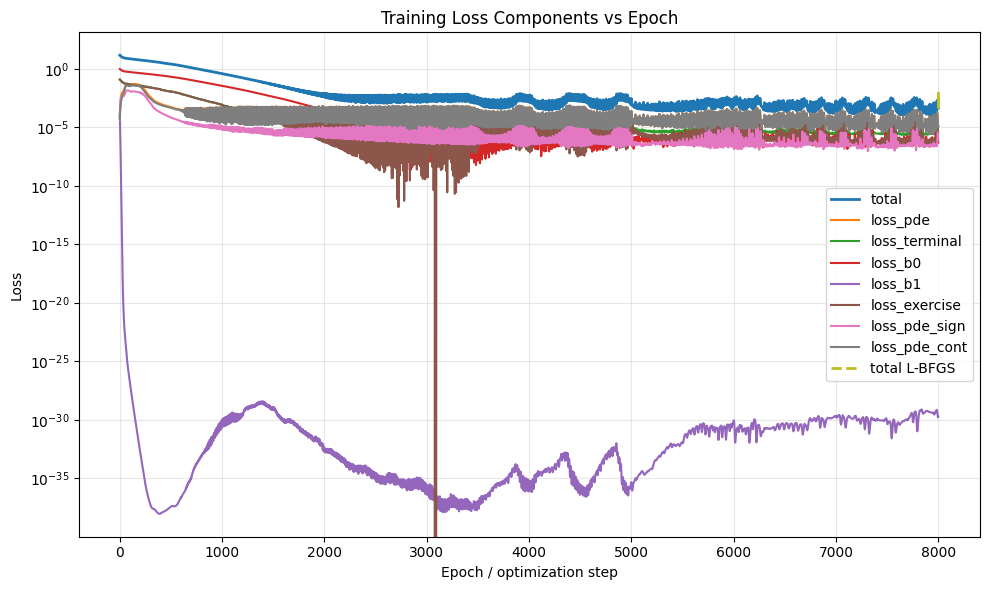

In [7]:
epochs_adam = np.arange(1, len(loss_history) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_adam, loss_history, label="total", linewidth=2)

for k, v in parts_history.items():
    plt.plot(epochs_adam, v, label=k)

if len(lbfgs_history) > 0:
    lbfgs_x = np.arange(len(loss_history) + 1, len(loss_history) + len(lbfgs_history) + 1)
    plt.plot(lbfgs_x, lbfgs_history, label="total L-BFGS", linewidth=2, linestyle="--")
plt.yscale("log")
plt.xlabel("Epoch / optimization step")
plt.ylabel("Loss")
plt.title("Training Loss Components vs Epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Evaluation

We compare PINN against the Binomial Tree (American put benchmark) on a full (S, t) grid.
We report both **global** and **ATM-band** (S ∈ [80, 120]) errors.

In [8]:
model.eval()

nS = 60
nT = 30

S_grid_np = np.linspace(S_min + 1.0, S_max, nS)
t_grid_np = np.linspace(t_min + 0.01, t_max - 0.01, nT)

print("Computing Binomial Tree reference grid")

V_tree_np = np.zeros((nS, nT))

for j, t_val in enumerate(t_grid_np):
    tau = T - t_val
    V_tree_np[:, j] = tree.price_grid(S_grid_np, K, tau, option_type="put")

SS_np, TT_np = np.meshgrid(S_grid_np, t_grid_np, indexing="ij")

dtype = next(model.parameters()).dtype

S_test = torch.tensor(SS_np.reshape(-1, 1), dtype=dtype, device=device)
t_test = torch.tensor(TT_np.reshape(-1, 1), dtype=dtype, device=device)

with torch.no_grad():
    V_pred = model(S_test, t_test).cpu().numpy().reshape(nS, nT)

abs_error = np.abs(V_pred - V_tree_np)
rel_l2 = np.linalg.norm(V_pred - V_tree_np) / (np.linalg.norm(V_tree_np) + 1e-12)
rmse = np.sqrt(np.mean((V_pred - V_tree_np) ** 2))
max_err = np.max(abs_error)

atm_mask = (S_grid_np >= 80.0) & (S_grid_np <= 120.0)

rel_l2_atm = (np.linalg.norm(V_pred[atm_mask, :] - V_tree_np[atm_mask, :]) / (np.linalg.norm(V_tree_np[atm_mask, :]) + 1e-12))

max_err_atm = np.max(abs_error[atm_mask, :])
payoff_np = np.maximum(K - SS_np, 0.0)
exercise_violation = np.max(np.maximum(payoff_np - V_pred, 0.0))

print("\nEvaluation vs Binomial Tree (American put benchmark):")
print(f"  Relative L2 error (global)  : {rel_l2:.6e}")
print(f"  Relative L2 error (ATM band): {rel_l2_atm:.6e}")
print(f"  RMSE                        : {rmse:.6e}")
print(f"  Max abs error (global)      : {max_err:.6e}")
print(f"  Max abs error (ATM)         : {max_err_atm:.6e}")
print(f"  Max exercise violation      : {exercise_violation:.6e}")

Computing Binomial Tree reference grid

Evaluation vs Binomial Tree (American put benchmark):
  Relative L2 error (global)  : 2.587073e-03
  Relative L2 error (ATM band): 7.922139e-03
  RMSE                        : 1.061234e-01
  Max abs error (global)      : 7.094803e-01
  Max abs error (ATM)         : 3.772731e-01
  Max exercise violation      : 5.565809e-01


## Single Cases

For each $t$ slice we print:
- Summary error metrics (global + ATM Rel L2, RMSE, max errors)
- A **pointwise table**: S | PINN | Tree (American) | BS European | EE Premium | Abs error | Rel error %
- A **two-panel plot**: prices (left) and relative error log-scale (right)


In [9]:
def compare_prices_table(model, S_list, t_value=0.5):
    model.eval()

    tau = T - t_value
    S_arr = np.asarray(S_list, dtype=float)

    tree_p = tree.price_grid(S_arr, K, tau, option_type="put")
    bs_p = bs.price_grid(S_arr, K, tau, option_type="put")

    dtype = next(model.parameters()).dtype

    S_t = torch.tensor(S_arr.reshape(-1, 1), dtype=dtype, device=device)
    t_t = torch.full_like(S_t, float(t_value))

    with torch.no_grad():
        pinn_p = model(S_t, t_t).cpu().numpy().flatten()

    abs_err = np.abs(pinn_p - tree_p)
    rel_err = abs_err / np.maximum(tree_p, 0.1) * 100.0
    ee_premium = tree_p - bs_p
    exercise_violation = np.maximum(np.maximum(K - S_arr, 0.0) - pinn_p, 0.0)

    return pd.DataFrame({
        "S": S_arr,
        "t": t_value,
        "PINN (American)": np.round(pinn_p, 4),
        "Tree (American)": np.round(tree_p, 4),
        "BS (European)": np.round(bs_p, 4),
        "EE Premium": np.round(ee_premium, 4),
        "Abs error": np.round(abs_err, 4),
        "Rel error %": np.round(rel_err, 3),
        "Exercise violation": np.round(exercise_violation, 4),
        "_pinn_raw": pinn_p,
        "_tree_raw": tree_p,
    })

S_values = [40, 60, 70, 80, 90, 100, 110, 120, 140, 160]

for t_val in [0.25, 0.5, 0.75]:
    df = compare_prices_table(model, S_values, t_value=t_val)

    atm_mask = df["S"].between(80, 120)

    pinn_arr = df["_pinn_raw"].values
    tree_arr = df["_tree_raw"].values

    pinn_atm = df.loc[atm_mask, "_pinn_raw"].values
    tree_atm = df.loc[atm_mask, "_tree_raw"].values

    rel_l2_f = np.linalg.norm(pinn_arr - tree_arr) / (np.linalg.norm(tree_arr) + 1e-12)
    rel_l2_atm = np.linalg.norm(pinn_atm - tree_atm) / (np.linalg.norm(tree_atm) + 1e-12)

    print(f"{'=' * 65}")
    print(f"  t = {t_val}  (tau = {T - t_val:.2f}),  K={K}, r={r}, sigma={sigma}")
    print(f"{'=' * 65}")
    print(f"  Rel L2 (full slice)  : {rel_l2_f:.6e}")
    print(f"  Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
    print(f"  Max rel error        : {df['Rel error %'].max():.4f}%")
    print(f"  Max exercise viol.   : {df['Exercise violation'].max():.4e}")
    print()

    display_cols = [c for c in df.columns if not c.startswith("_")]
    print(df[display_cols].to_string(index=False))
    print()

  t = 0.25  (tau = 0.75),  K=100.0, r=0.05, sigma=0.2
  Rel L2 (full slice)  : 1.703566e-03
  Rel L2 (ATM [80,120]): 4.529423e-03
  Max rel error        : 8.3040%
  Max exercise viol.   : 9.5300e-02

    S    t  PINN (American)  Tree (American)  BS (European)  EE Premium  Abs error  Rel error %  Exercise violation
 40.0 0.25        59.965599          60.0000        56.3194      3.6806     0.0344        0.057              0.0344
 60.0 0.25        39.936501          40.0000        36.3319      3.6681     0.0635        0.159              0.0635
 70.0 0.25        29.949600          30.0000        26.5011      3.4989     0.0504        0.168              0.0504
 80.0 0.25        19.904699          20.0000        17.4195      2.5805     0.0953        0.477              0.0953
 90.0 0.25        11.107400          11.1110        10.0747      1.0363     0.0036        0.033              0.0000
100.0 0.25         5.492500           5.4648         5.0917      0.3731     0.0277        0.508         

## Graphs

### Reference price heatmap (Binomial Tree)

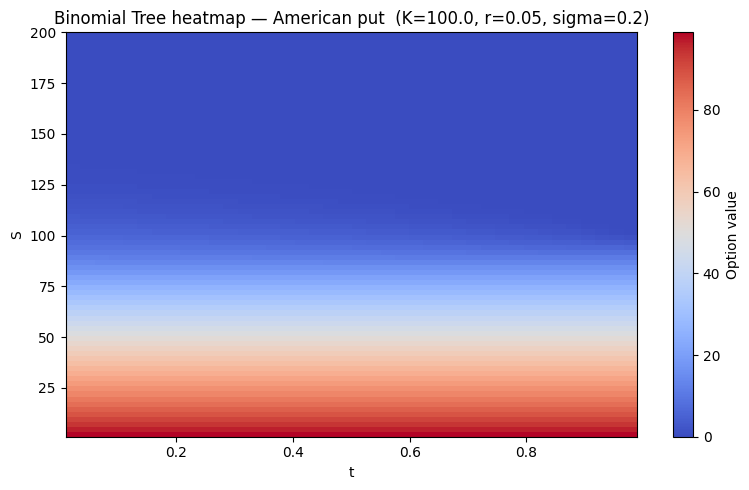

In [10]:
def plot_tree_heatmap(nS=80, nT=40):
    S_vals = np.linspace(S_min + 1.0, S_max, nS)
    t_vals = np.linspace(t_min + 0.01, t_max - 0.01, nT)
    V_tree = np.zeros((nS, nT))
    for j, t_val in enumerate(t_vals):
        V_tree[:, j] = tree.price_grid(S_vals, K, T - t_val, option_type="put")
    plt.figure(figsize=(8, 5))
    im = plt.imshow(V_tree,
                    extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                    origin="lower", aspect="auto", cmap="coolwarm")
    plt.xlabel("t"); plt.ylabel("S")
    plt.title(f"Binomial Tree heatmap — American put  (K={K}, r={r}, sigma={sigma})")
    plt.colorbar(im, label="Option value")
    plt.tight_layout(); plt.show()

plot_tree_heatmap()

### PINN vs Binomial Tree vs BS European - slice plots with relative error


 t=0.25, tau=0.750
 Rel L2 (full slice)  : 1.386441e-03
 Rel L2 (ATM [80,120]): 3.988525e-03
 RMSE                 : 5.665244e-02
 Max abs error        : 2.494224e-01
 Max rel error        : 11.4089%
 Max exercise viol.   : 2.494224e-01
 Exercise boundary    : S* ≈ 84.2907


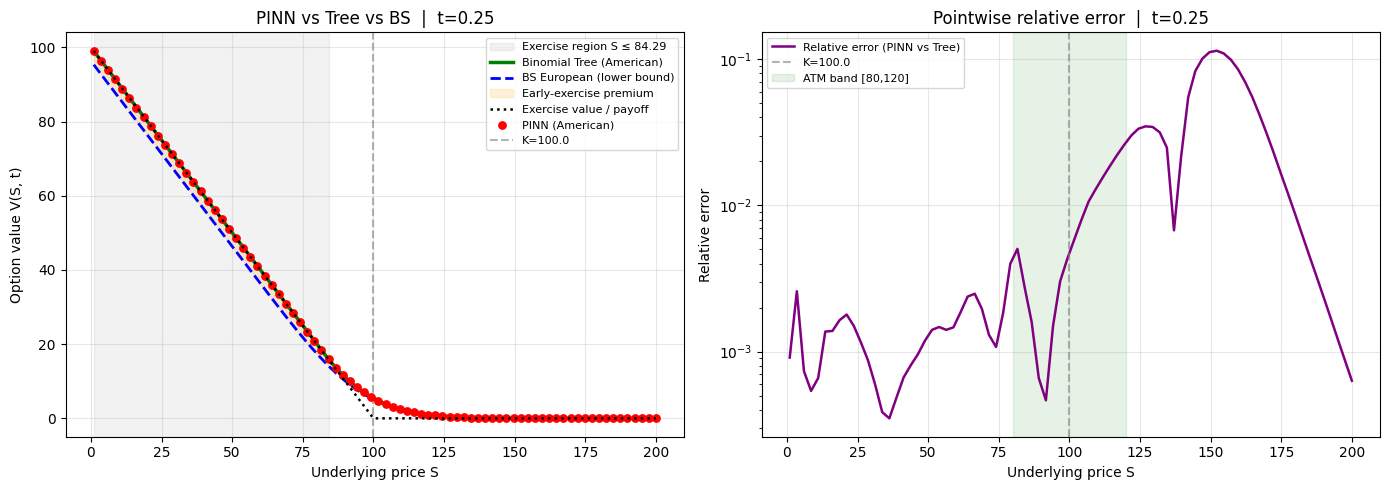


 t=0.5, tau=0.500
 Rel L2 (full slice)  : 1.173986e-03
 Rel L2 (ATM [80,120]): 3.208707e-03
 RMSE                 : 4.795596e-02
 Max abs error        : 2.987235e-01
 Max rel error        : 6.9265%
 Max exercise viol.   : 2.987235e-01
 Exercise boundary    : S* ≈ 85.7870


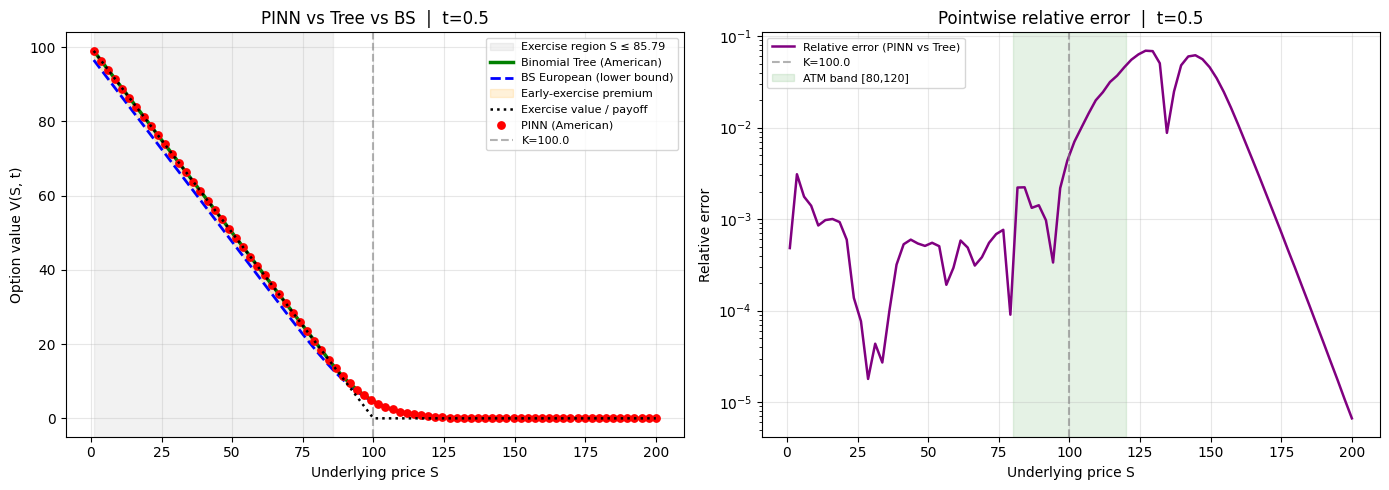


 t=0.75, tau=0.250
 Rel L2 (full slice)  : 2.777858e-03
 Rel L2 (ATM [80,120]): 8.832556e-03
 RMSE                 : 1.134369e-01
 Max abs error        : 3.395942e-01
 Max rel error        : 19.9032%
 Max exercise viol.   : 3.395942e-01
 Exercise boundary    : S* ≈ 88.7794


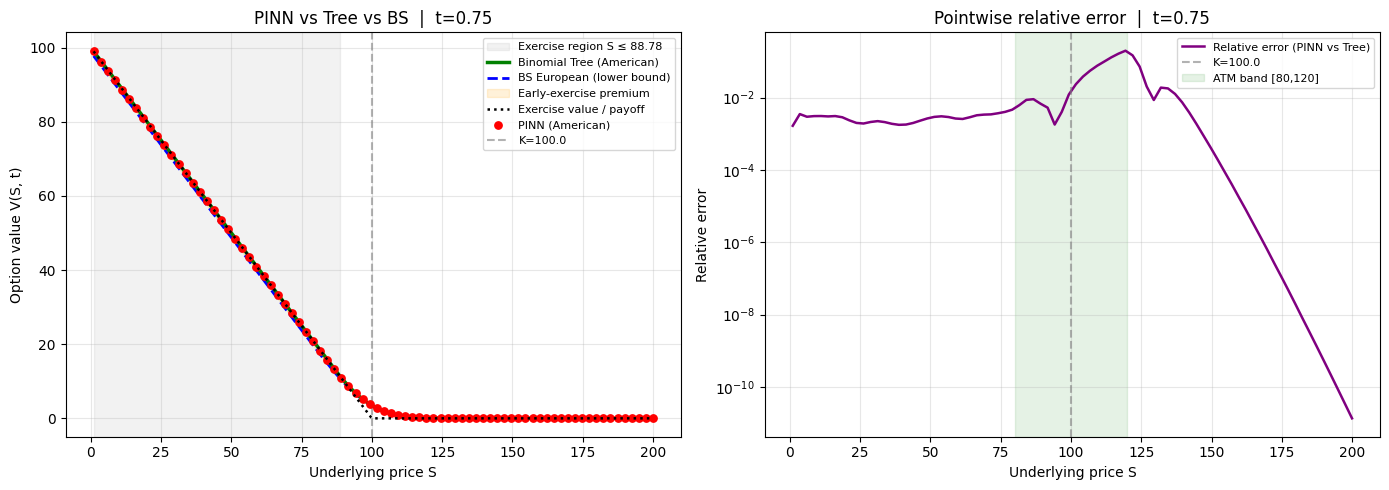

In [11]:
def plot_single_slice(model, t_value=0.5, nS_line=400, nS_scatter=80):
    """
    Two-panel plot:
      Left  - option prices: PINN vs Tree (American) vs BS (European)
      Right - pointwise relative error PINN vs Tree (log scale)
    Also prints full error summary.
    """
    model.eval()

    tau = T - t_value

    S_line_np = np.linspace(S_min + 1.0, S_max, nS_line)
    S_scatter_np = np.linspace(S_min + 1.0, S_max, nS_scatter)

    tree_line = tree.price_grid(S_line_np, K, tau, option_type="put")
    tree_scatter = tree.price_grid(S_scatter_np, K, tau, option_type="put")
    bs_line = bs.price_grid(S_line_np, K, tau, option_type="put")
    payoff_line = np.maximum(K - S_line_np, 0.0)

    dtype = next(model.parameters()).dtype

    S_t = torch.tensor(S_scatter_np.reshape(-1, 1), dtype=dtype, device=device)
    t_t = torch.full_like(S_t, float(t_value))

    with torch.no_grad():
        pinn_scatter = model(S_t, t_t).cpu().numpy().flatten()

    abs_err = np.abs(pinn_scatter - tree_scatter)
    rel_err = abs_err / np.maximum(tree_scatter, 0.1)

    atm_mask = (S_scatter_np >= 80.0) & (S_scatter_np <= 120.0)

    rel_l2_sl = (np.linalg.norm(pinn_scatter - tree_scatter) / (np.linalg.norm(tree_scatter) + 1e-12))

    rel_l2_atm = (np.linalg.norm(pinn_scatter[atm_mask] - tree_scatter[atm_mask]) / (np.linalg.norm(tree_scatter[atm_mask]) + 1e-12))

    rmse = np.sqrt(np.mean((pinn_scatter - tree_scatter) ** 2))
    max_abs_err = np.max(abs_err)
    max_rel_err = np.max(rel_err)

    payoff_scatter = np.maximum(K - S_scatter_np, 0.0)
    exercise_violation = np.max(np.maximum(payoff_scatter - pinn_scatter, 0.0))

    tol = 1e-3 * K
    exercise_mask = (S_line_np <= K) & (np.abs(tree_line - payoff_line) < tol)

    print(f"\n{'=' * 55}")
    print(f" t={t_value}, tau={tau:.3f}")
    print(f"{'=' * 55}")
    print(f" Rel L2 (full slice)  : {rel_l2_sl:.6e}")
    print(f" Rel L2 (ATM [80,120]): {rel_l2_atm:.6e}")
    print(f" RMSE                 : {rmse:.6e}")
    print(f" Max abs error        : {max_abs_err:.6e}")
    print(f" Max rel error        : {max_rel_err:.4%}")
    print(f" Max exercise viol.   : {exercise_violation:.6e}")

    if exercise_mask.any():
        S_star = S_line_np[exercise_mask].max()
        print(f" Exercise boundary    : S* ≈ {S_star:.4f}")
    else:
        S_star = None
        print(f" Exercise boundary    : not detected")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]

    if S_star is not None:
        ax.axvspan(S_line_np.min(), S_star, alpha=0.10, color="gray", label=f"Exercise region S ≤ {S_star:.2f}", zorder=0)

    ax.plot(S_line_np, tree_line, color="green", lw=2.5, label="Binomial Tree (American)", zorder=3)
    ax.plot(S_line_np, bs_line, color="blue", lw=2.0, ls="--", label="BS European (lower bound)", zorder=2)
    ax.fill_between(S_line_np, bs_line, tree_line, alpha=0.15, color="orange", label="Early-exercise premium", zorder=1)
    ax.plot(S_line_np, payoff_line, color="black", lw=1.8, ls=":", label="Exercise value / payoff", zorder=5)
    ax.scatter(S_scatter_np, pinn_scatter, color="red", s=28, label="PINN (American)", zorder=4)
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.set_xlabel("Underlying price S")
    ax.set_ylabel("Option value V(S, t)")
    ax.set_title(f"PINN vs Tree vs BS  |  t={t_value}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    ax.semilogy(S_scatter_np, rel_err, color="purple", lw=1.8, label="Relative error (PINN vs Tree)")
    ax.axvline(K, color="gray", ls="--", alpha=0.6, label=f"K={K}")
    ax.axvspan(80, 120, alpha=0.10, color="green", label="ATM band [80,120]")
    ax.set_xlabel("Underlying price S")
    ax.set_ylabel("Relative error")
    ax.set_title(f"Pointwise relative error  |  t={t_value}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

for t_val in [0.25, 0.5, 0.75]:
    plot_single_slice(model, t_value=t_val)

### Error Heatmap - |PINN - Binomial Tree|

Max abs error          : 7.094803e-01
Mean abs error         : 5.920126e-02
Max relative error     : 3.772731e-01
Max exercise violation : 5.565809e-01


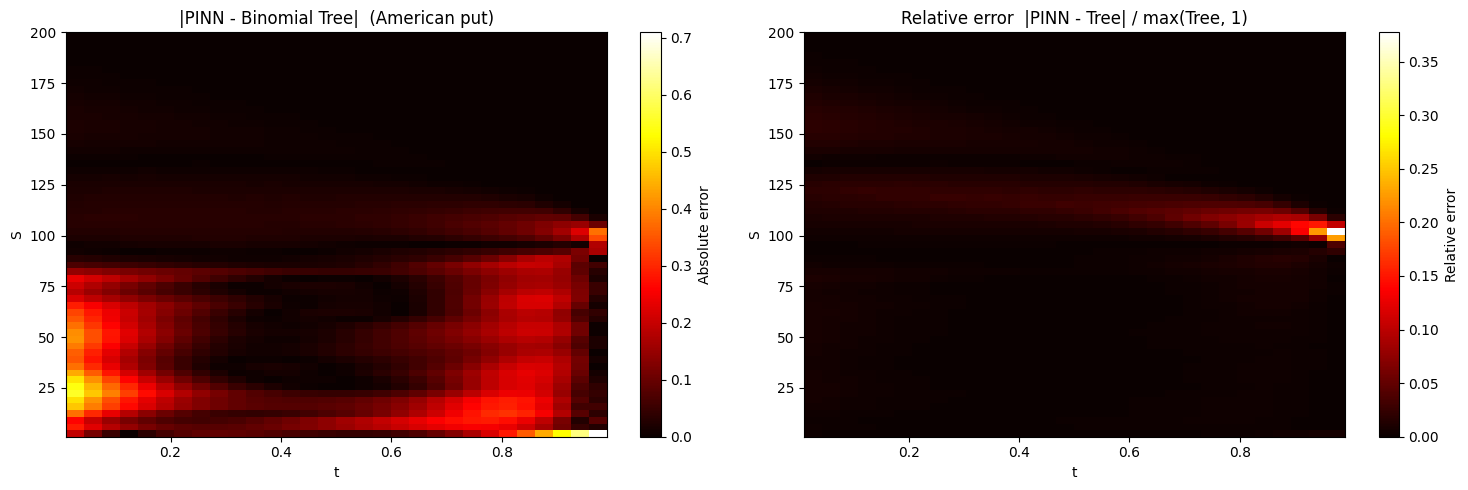

In [12]:
def plot_error_heatmap(model, nS=60, nT=30):
    model.eval()

    S_vals = np.linspace(S_min + 1.0, S_max, nS)
    t_vals = np.linspace(t_min + 0.01, t_max - 0.01, nT)

    V_tree = np.zeros((nS, nT))
    for j, t_val in enumerate(t_vals):
        V_tree[:, j] = tree.price_grid(S_vals, K, T - t_val, option_type="put")

    SS, TT = np.meshgrid(S_vals, t_vals, indexing="ij")

    dtype = next(model.parameters()).dtype

    S_t = torch.tensor(SS.reshape(-1, 1), dtype=dtype, device=device)
    t_t = torch.tensor(TT.reshape(-1, 1), dtype=dtype, device=device)

    with torch.no_grad():
        V_pinn = model(S_t, t_t).cpu().numpy().reshape(nS, nT)

    abs_err = np.abs(V_pinn - V_tree)
    rel_err = abs_err / np.maximum(V_tree, 1.0)

    payoff = np.maximum(K - SS, 0.0)
    exercise_violation = np.maximum(payoff - V_pinn, 0.0)

    print(f"Max abs error          : {abs_err.max():.6e}")
    print(f"Mean abs error         : {abs_err.mean():.6e}")
    print(f"Max relative error     : {rel_err.max():.6e}")
    print(f"Max exercise violation : {exercise_violation.max():.6e}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    im0 = axes[0].imshow(abs_err, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                         origin="lower", aspect="auto", cmap="hot")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("S")
    axes[0].set_title("|PINN - Binomial Tree|  (American put)")
    fig.colorbar(im0, ax=axes[0], label="Absolute error")

    im1 = axes[1].imshow(rel_err, extent=[t_vals.min(), t_vals.max(), S_vals.min(), S_vals.max()],
                         origin="lower", aspect="auto", cmap="hot")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("S")
    axes[1].set_title("Relative error  |PINN - Tree| / max(Tree, 1)")
    fig.colorbar(im1, ax=axes[1], label="Relative error")

    plt.tight_layout()
    plt.show()

plot_error_heatmap(model)

### PINN vs Tree vs BS across time slices

Because the PINN learned the **full 2D surface**, we can query it at any $(S, t)$.
Each panel shows one time slice with all three methods and the early-exercise premium (shaded).
The left boundary of the orange region marks the **free boundary**, the critical $S^*$ below which early exercise is optimal.


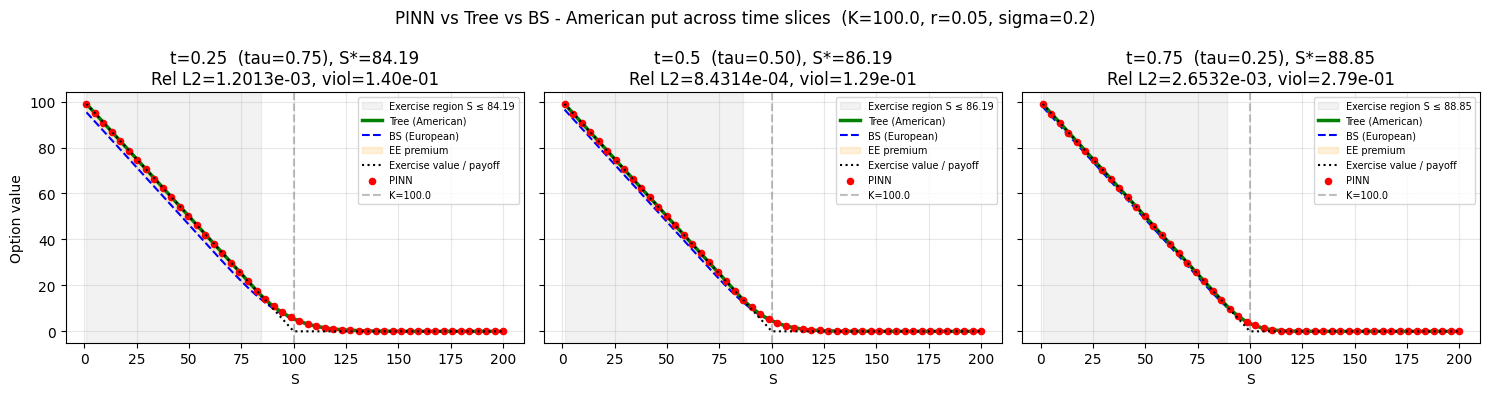

In [13]:
def plot_pinn_vs_tree_multiple_t(model, t_values=None, nS_line=300, nS_scatter=50):
    if t_values is None:
        t_values = [0.25, 0.5, 0.75]

    model.eval()

    S_line = np.linspace(S_min + 1.0, S_max, nS_line)
    S_scatter = np.linspace(S_min + 1.0, S_max, nS_scatter)

    dtype = next(model.parameters()).dtype

    fig, axes = plt.subplots(1, len(t_values), figsize=(5 * len(t_values), 4), sharey=True)

    if len(t_values) == 1:
        axes = [axes]

    for ax, t_val in zip(axes, t_values):
        tau = T - t_val

        tree_line = tree.price_grid(S_line, K, tau, option_type="put")
        tree_scatter = tree.price_grid(S_scatter, K, tau, option_type="put")
        bs_line = bs.price_grid(S_line, K, tau, option_type="put")
        payoff_line = np.maximum(K - S_line, 0.0)
        payoff_scatter = np.maximum(K - S_scatter, 0.0)

        S_t = torch.tensor(S_scatter.reshape(-1, 1), dtype=dtype, device=device)
        t_t = torch.full_like(S_t, float(t_val))

        with torch.no_grad():
            pinn_scatter = model(S_t, t_t).cpu().numpy().flatten()

        rel_l2 = (np.linalg.norm(pinn_scatter - tree_scatter) / (np.linalg.norm(tree_scatter) + 1e-12))

        exercise_violation = np.max(np.maximum(payoff_scatter - pinn_scatter, 0.0))

        tol = 1e-3 * K
        exercise_mask = (S_line <= K) & (np.abs(tree_line - payoff_line) < tol)

        if exercise_mask.any():
            S_star = S_line[exercise_mask].max()
            ax.axvspan(S_line.min(), S_star, alpha=0.10, color="gray", label=f"Exercise region S ≤ {S_star:.2f}", zorder=0)
            boundary_text = f", S*={S_star:.2f}"
        else:
            S_star = None
            boundary_text = ""

        ax.plot(S_line, tree_line, color="green", lw=2.5, label="Tree (American)", zorder=3)
        ax.plot(S_line, bs_line, color="blue", lw=1.5, ls="--", label="BS (European)", zorder=2)
        ax.fill_between(S_line, bs_line, tree_line, alpha=0.15, color="orange", label="EE premium", zorder=1)
        ax.plot(S_line, payoff_line, color="black", lw=1.5, ls=":", label="Exercise value / payoff", zorder=5)
        ax.scatter(S_scatter, pinn_scatter, color="red", s=20, label="PINN", zorder=4)
        ax.axvline(K, color="gray", ls="--", alpha=0.5, label=f"K={K}")

        ax.set_title(f"t={t_val}  (tau={tau:.2f}){boundary_text}\n"
                     f"Rel L2={rel_l2:.4e}, viol={exercise_violation:.2e}")
        ax.set_xlabel("S")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7)

    axes[0].set_ylabel("Option value")

    fig.suptitle(f"PINN vs Tree vs BS - American put across time slices  "
                 f"(K={K}, r={r}, sigma={sigma})", fontsize=12)
    plt.tight_layout()
    plt.show()

plot_pinn_vs_tree_multiple_t(model, t_values=[0.25, 0.5, 0.75])

### Free boudary $S^*(t)$ from the American PINN

For an American put, the early-exercise / free boundary is the largest stock price where immediate exercise is optimal:

$$
S^*(t) = \sup\{S \le K: V(S,t) \approx (K-S)^+\}.
$$

The code below evaluates the trained PINN on a dense $S$-grid for every time $t$ in a grid, detects the contact point with the payoff, stores it in a DataFrame, and plots $S^*(t)$.
A binomial-tree boundary is also plotted as a benchmark.

,t,tau,S_star_PINN,S_star_Tree,PINN_status,Tree_status,tol_used
0,0.000000,1.000000,84.831194,81.506919,ok,ok,0.210000
1,0.020408,0.979592,84.892992,81.580756,ok,ok,0.210000
2,0.040816,0.959184,84.956709,81.652557,ok,ok,0.210000
3,0.061224,0.938776,85.022154,81.760229,ok,ok,0.210000
4,0.081633,0.918367,85.089934,81.858801,ok,ok,0.210000
5,0.102041,0.897959,85.159474,81.927007,ok,ok,0.210000
6,0.122449,0.877551,85.232084,82.023823,ok,ok,0.210000
7,0.142857,0.857143,85.306585,82.137223,ok,ok,0.210000
8,0.163265,0.836735,85.384625,82.245762,ok,ok,0.210000
9,0.183673,0.816327,85.465964,82.353312,ok,ok,0.210000


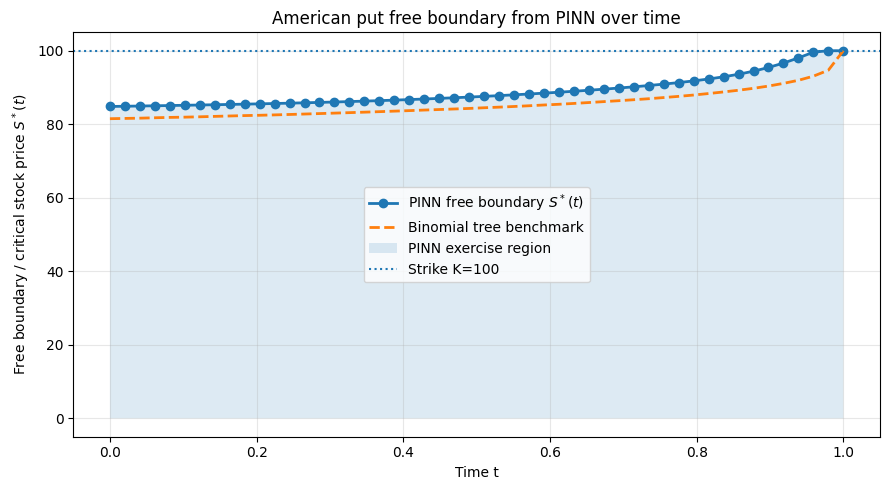

In [14]:
def _boundary_from_premium(S_vals, continuation_premium, tol):
    S_vals  = np.asarray(S_vals,  dtype=float)
    premium = np.asarray(continuation_premium, dtype=float)

    g = premium - tol
    positive_idx = np.where(g > 0.0)[0]

    if len(positive_idx) == 0:
        return float(S_vals[-1]), "all_exercise_on_grid"

    j = int(positive_idx[0])

    if j == 0:
        contact_idx = np.where(g <= 0.0)[0]
        if len(contact_idx) == 0:
            return np.nan, "not_detected"
        return float(S_vals[contact_idx[-1]]), "fallback_largest_contact"

    S0, S1 = S_vals[j - 1], S_vals[j]
    g0, g1 = g[j - 1], g[j]
    S_star = S0 if abs(g1 - g0) < 1e-12 else S0 + (0.0 - g0) * (S1 - S0) / (g1 - g0)
    return float(S_star), "ok"


def compute_free_boundary_pinn_vs_tree(model, n_t=50, n_s=800, tol=None, batch_size=20_000):
    model.eval()

    if tol is None:
        tol = 5e-3 * K

    S_vals      = np.linspace(max(S_min + 1e-6, 1e-6), K, n_s)
    t_vals      = np.linspace(t_min, t_max, n_t)
    payoff_vals = np.maximum(K - S_vals, 0.0)
    dtype       = next(model.parameters()).dtype

    SS, TT = np.meshgrid(S_vals, t_vals, indexing="ij")   # (n_s, n_t)
    S_torch = torch.tensor(SS.reshape(-1, 1), dtype=dtype, device=device)
    t_torch = torch.tensor(TT.reshape(-1, 1), dtype=dtype, device=device)

    V_flat = []
    with torch.no_grad():
        for start in range(0, len(S_torch), batch_size):
            V_flat.append(
                model(S_torch[start:start + batch_size],
                      t_torch[start:start + batch_size])
                .cpu().numpy().ravel()
            )
    V_pinn_grid = np.concatenate(V_flat).reshape(n_s, n_t)  # (n_s, n_t)

    tree_fast = BinomialTree(r, sigma, N=150)

    rows = []

    for idx_t, t_val in enumerate(t_vals):
        tau   = T - t_val
        tol_tau = tol + 0.03 * K * np.exp(-tau / 0.05)

        if tau <= 1e-12:
            S_star_pinn, status_pinn = K, "forced_maturity_K"
        else:
            premium_pinn = V_pinn_grid[:, idx_t] - payoff_vals
            S_star_pinn, status_pinn = _boundary_from_premium(S_vals, premium_pinn, tol_tau)

        V_tree      = tree_fast.price_grid(S_vals, K, tau, option_type="put")
        premium_tree = V_tree - payoff_vals
        S_star_tree, status_tree = _boundary_from_premium(S_vals, premium_tree, tol=1e-5 * K)

        rows.append({
            "t":           t_val,
            "tau":         tau,
            "S_star_PINN": S_star_pinn,
            "S_star_Tree": S_star_tree,
            "PINN_status": status_pinn,
            "Tree_status": status_tree,
            "tol_used":    tol_tau,
        })

    return pd.DataFrame(rows)


def plot_free_boundary(boundary_df):
    plt.figure(figsize=(9, 5))
    plt.plot(boundary_df["t"], boundary_df["S_star_PINN"],
             marker="o", linewidth=2, label="PINN free boundary $S^*(t)$")
    if "S_star_Tree" in boundary_df.columns:
        plt.plot(boundary_df["t"], boundary_df["S_star_Tree"],
                 linestyle="--", linewidth=2, label="Binomial tree benchmark")
    plt.fill_between(boundary_df["t"], S_min, boundary_df["S_star_PINN"],
                     alpha=0.15, label="PINN exercise region")
    plt.axhline(K, linestyle=":", linewidth=1.5, label=f"Strike K={K:g}")
    plt.xlabel("Time t")
    plt.ylabel("Free boundary / critical stock price $S^*(t)$")
    plt.title("American put free boundary from PINN over time")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

boundary_df = compute_free_boundary_pinn_vs_tree(model, n_t=50, n_s=800, tol=2.1e-3 * K)
display(boundary_df)
plot_free_boundary(boundary_df)